Pressure–temperature parameterizations
======================================

Set the parameterization with ``ptype`` in `utils.Retrieval_params`.
Profiles are evaluated by `TPmod.set_prof` on ``ModelConfig.press``.
Most analytic profiles are smoothed with a five-layer Gaussian kernel and the
current implementation limits temperatures to the opacity-table range.

Available profiles
------------------


| ``ptype``                  | Model                                                                                                             | Retrieved parameters                                                     | When to use it               |                                                                                              
| ---------------------- | ------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------- |-------------------------------------------------------------------- |
| **1**       | Free spline (Line-style)             | ``gamma``, ``T_1`` … ``T_n``                         | Flexible profile on n coarse pressure knots. Default is n = 13. ``gamma`` controls the smoothing prior used during retrieval.            |
| **2**       | Madhusudhan & Seager, no inversion             | ``alpha1``, ``alpha2``, ``logP1``, ``logP3``, ``T3``                         | Compact three-zone monotonic profile with an isothermal deep region.            |
| **3**     | Madhusudhan & Seager, inversion                | type 2 plus ``logP2`` | Allows the middle atmospheric zone to contain a thermal inversion.|
| **4**     | Zhang-style gradient profile                   |``Tbottom``, ``dTdP1`` … ``dTdPn``              | Retrieves logarithmic temperature gradients at n pressures from $e^{3}$ to $e^{-3}$ bar and integrates upward. Default is n = 6|
| **7**     | Mollière hybrid radiative–convective           | ``Tint``, ``alpha``, ``lndelta``, ``T1``, ``T2``, ``T3`` | Joins upper spline temperatures to an Eddington radiative structure and a deep dry adiabat.|
| **9** | Fixed input profile | none | Interpolates ``ModelConfig.prof`` and does not retrieve temperatures.|


Example comparison
------------------

In [3]:
import sys
sys.path.append('../../../')
import numpy as np
import matplotlib.pyplot as plt
import TPmod


In [5]:
press = np.logspace(-4, 2.4, 64)
coarsePress = np.logspace(-4, 2.4, 13)

Type 1

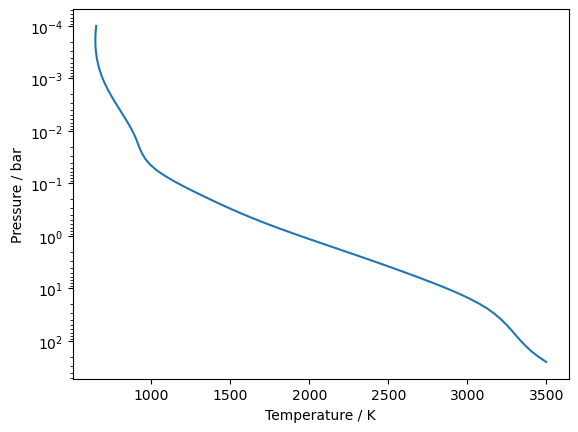

In [13]:
# Type 1: T1 ...  T13
pars = np.array([650,650,700,800,900,1000,1300,1700,2200,2700,3100,3300,3500])
temperature = TPmod.set_prof(1, coarsePress, press, pars)

plt.plot(temperature, press)
plt.yscale("log")
plt.gca().invert_yaxis()
plt.xlabel("Temperature / K")
plt.ylabel("Pressure / bar")
plt.show()

Type 2

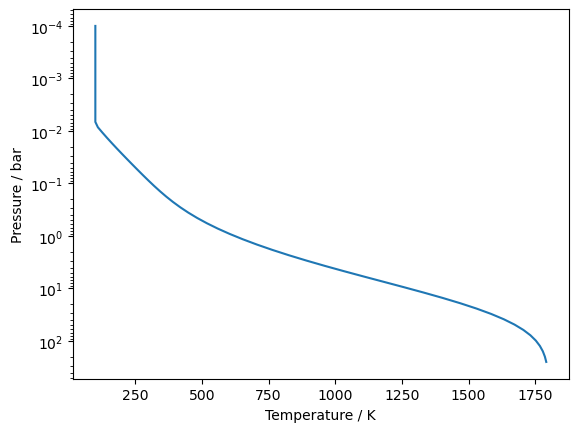

In [ ]:
# Type 2: alpha1, alpha2, logP1, logP3, T3
pars = np.array([0.35, 0.15, -1.0, 1.5, 1800.0])
temperature = TPmod.set_prof(2, None, press, pars)

plt.plot(temperature, press)
plt.yscale("log")
plt.gca().invert_yaxis()
plt.xlabel("Temperature / K")
plt.ylabel("Pressure / bar")
plt.show()

Type 3

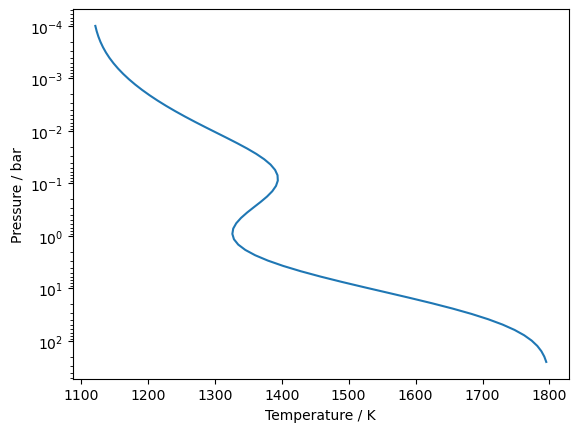

In [ ]:
# Type 3: alpha1, alpha2, logP1, logP2, logP3, T3,
pars = np.array([0.35, 0.15, -1.0, 0, 1.5, 1800.0])
temperature = TPmod.set_prof(3, None, press, pars)

plt.plot(temperature, press)
plt.yscale("log")
plt.gca().invert_yaxis()
plt.xlabel("Temperature / K")
plt.ylabel("Pressure / bar")
plt.show()

Type 4

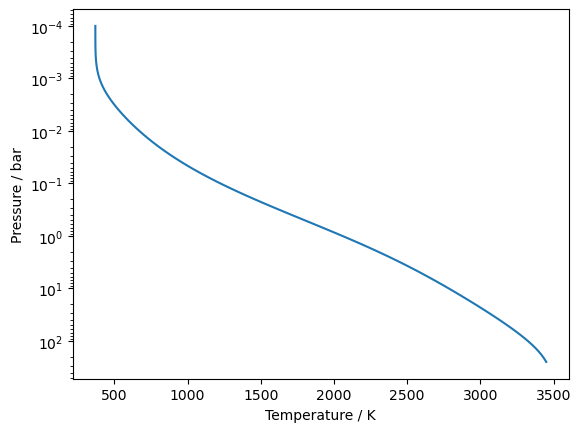

In [24]:
# Type 4: Tbottom, dTdP1... dTdP6
press4 = np.logspace(-4, 2.4, 100)
coarsePress4 = np.logspace(-4, 2.4, 6)
pars = np.array([3500, 0.26, 0.26, 0.25, 0.12, 0.07,0])
temperature = TPmod.set_prof(4, coarsePress4, press4, pars)

plt.plot(temperature, press4)
plt.yscale("log")
plt.gca().invert_yaxis()
plt.xlabel("Temperature / K")
plt.ylabel("Pressure / bar")
plt.show()

Type 7

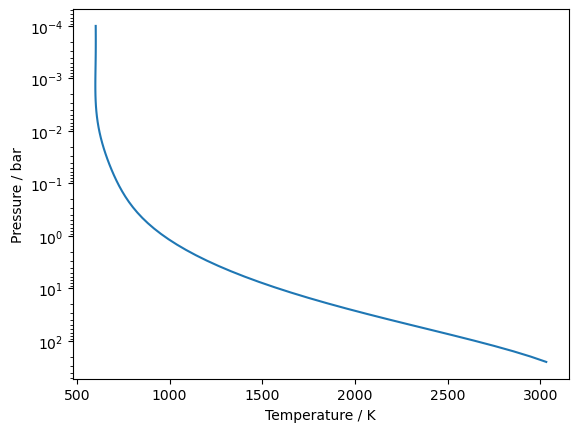

In [26]:
# Type 4: Tint, alpha, lndelta, T1, T2, T3
pars = np.array([800, 1, 0.5, 600, 600, 600])
temperature = TPmod.set_prof(7, coarsePress, press, pars)

plt.plot(temperature, press)
plt.yscale("log")
plt.gca().invert_yaxis()
plt.xlabel("Temperature / K")
plt.ylabel("Pressure / bar")
plt.show()

Important constraints
---------------------

The priors in `Priors` enforce parameter ordering and physical bounds that
are not obvious from the raw parameter names. In particular, transition
pressures must remain ordered, type-7 upper temperatures must connect sensibly
to the radiative profile, and evaluated temperatures must remain within the
model opacity range. Treat ``utils.Retrieval_params.pt_dic_gen`` as the source
of default parameter definitions and `Priors` as the source of coupled
constraints.